# **Intro ML Week 3.2 - Resampling**
---
**Resampling Methods**

In [1]:
# Import the required libraries.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Load the data.
x = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10])
y = (2*x + 3)**2

data = pd.DataFrame({'x': x,
                     'y': y})

data

,x,y
0,1,25
1,2,49
2,3,81
3,4,121
4,5,169
5,6,225
6,7,289
7,8,361
8,9,441
9,10,529


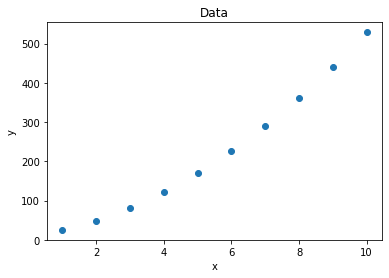

In [3]:
# Plot the data.
plt.scatter(data['x'], data['y'])

plt.xlabel('x')
plt.ylabel('y')
plt.title('Data')
plt.show()

## **1. Random Sampling**
---
- Random Sampling without replacement
- Random Sampling with replacement

- We can use `pd.sample` function.

Read more: [here](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.sample.html)

In [4]:
# Random Sampling without replacement using n_sample.
n_sample = 5
data.sample(n = n_sample)

,x,y
7,8,361
5,6,225
9,10,529
0,1,25
4,5,169


In [5]:
# Random Sampling without replacement using frac_sample.
frac_sample = 0.7
data.sample(frac = frac_sample)

,x,y
1,2,49
8,9,441
4,5,169
2,3,81
5,6,225
7,8,361
9,10,529


In [6]:
# Do Random Sampling without replacement 10 times.
for i in range(10):
    data_sample = data.sample(n = n_sample)
    index_data_sample = data_sample.index.to_list()

    print(f"Index sample ke-{i+1} : {index_data_sample}")

Index sample ke-1 : [7, 0, 8, 6, 9]
Index sample ke-2 : [6, 0, 8, 5, 9]
Index sample ke-3 : [7, 5, 2, 0, 9]
Index sample ke-4 : [6, 8, 9, 0, 5]
Index sample ke-5 : [4, 7, 0, 3, 5]
Index sample ke-6 : [6, 4, 5, 1, 0]
Index sample ke-7 : [4, 6, 7, 1, 9]
Index sample ke-8 : [1, 8, 6, 0, 9]
Index sample ke-9 : [8, 0, 7, 4, 3]
Index sample ke-10 : [7, 1, 4, 3, 5]


In [7]:
# Random Sampling with replacement using n_sample.
n_sample = 5
data.sample(n = n_sample, replace = True)

,x,y
0,1,25
4,5,169
9,10,529
3,4,121
9,10,529


In [8]:
# Do Random Sampling with replacement 10 times.
for i in range(10):
    data_sample = data.sample(n = n_sample, replace=True)
    index_data_sample = data_sample.index.to_list()

    print(f"Index sample ke-{i+1} : {index_data_sample}")

Index sample ke-1 : [8, 0, 5, 9, 7]
Index sample ke-2 : [0, 3, 8, 0, 5]
Index sample ke-3 : [7, 2, 5, 6, 1]
Index sample ke-4 : [4, 5, 6, 6, 8]
Index sample ke-5 : [4, 4, 1, 7, 8]
Index sample ke-6 : [1, 9, 1, 9, 8]
Index sample ke-7 : [6, 7, 6, 0, 7]
Index sample ke-8 : [5, 0, 2, 0, 2]
Index sample ke-9 : [8, 7, 5, 6, 5]
Index sample ke-10 : [0, 5, 2, 1, 7]


## **2. Validation Set Approach**
---

- Some fraction of the data is randomly splitted into `train` and `valid` set.
- The drawbacks:
    1. Model performance depends on which set of data we got.
    2. The number of data used to train the model are reduced, which potentially leads to underfit/overfit.

In [9]:
# Load the data.
FNAME = "3.2-auto.csv"

df_auto = pd.read_csv(FNAME)

list_cols = ["displacement", "horsepower", "weight", "mpg"]
df_auto = df_auto[list_cols]
df_auto.head()

,displacement,horsepower,weight,mpg
0,307.0,130.0,3504.0,18.0
1,350.0,165.0,3693.0,15.0
2,318.0,150.0,3436.0,18.0
3,304.0,150.0,3433.0,16.0
4,302.0,140.0,3449.0,17.0


- In this experiment we try to split $50$% train and $50$% validation.
- Validation Set Approach use the idea of fraction random sampling without replacement.

- Define the `split_validation_set` function.
- It receives 2 arguments: `data` and `frac`
- It returns the set of `data_train` and `data_valid`.

In [10]:
# Function to split using validation set.
def split_validation_set(data, frac):
    """
    Split the data using the validation set approach
    """
    # Define the train set.
    data_train = data.sample(frac = frac)
    idx_train = list(data_train.index)

    # Define the valid set.
    data_valid = data.drop(index = idx_train)

    return data_train, data_valid

In [11]:
# Test the function.
fraction_train = 0.5

data_train, data_valid = split_validation_set(data = df_auto,
                                              frac = fraction_train)

print(f"Train set shape: {data_train.shape}")
print(f"Valid set shape: {data_valid.shape}")

Train set shape: (196, 4)
Valid set shape: (196, 4)


In [12]:
# Sanity check the train set.
data_train.head()

,displacement,horsepower,weight,mpg
362,112.0,88.0,2605.0,28.0
169,134.0,96.0,2702.0,24.0
389,135.0,84.0,2295.0,32.0
316,134.0,90.0,2711.0,29.8
251,200.0,95.0,3155.0,20.5


In [13]:
# Sanity check the valid set.
data_valid.head()

,displacement,horsepower,weight,mpg
0,307.0,130.0,3504.0,18.0
1,350.0,165.0,3693.0,15.0
2,318.0,150.0,3436.0,18.0
6,454.0,220.0,4354.0,14.0
8,455.0,225.0,4425.0,14.0


- Define the `split_input_output` function.
- It receives 2 argument: `data` and `output_col`.
- It returns the input (`X`) and the output (`y`).

In [14]:
# Function to split input-output.
def split_input_output(data, output_col):
    """
    Split the data into input and output
    """
    X = data.drop(columns = output_col)
    y = data[output_col]

    return X, y

In [15]:
# Test the function.
OUTPUT_COL = "mpg"

X_train, y_train = split_input_output(data_train, OUTPUT_COL)
X_valid, y_valid = split_input_output(data_valid, OUTPUT_COL)

- Let's do some prediction using `DecisionTreeRegressor`.

Read more: [here](https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html)

In [16]:
# Import the DecisionTreeRegressor class.
from sklearn.tree import DecisionTreeRegressor

In [17]:
# Create model object.
dt_reg = DecisionTreeRegressor()

# Fit the model.
dt_reg.fit(X_train, y_train)

DecisionTreeRegressor()

In [18]:
# Predict the data.
y_train_pred = dt_reg.predict(X_train)
y_valid_pred = dt_reg.predict(X_valid)

- Scikit-learn has some function to assess the model performance.
- We will use the `root_mean_squared_error` function.

Read more: [here](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.root_mean_squared_error.html)

In [19]:
# Import the root_mean_squared_error function.
from sklearn.metrics import root_mean_squared_error as RMSE

In [20]:
# Test the function.
rmse_train = RMSE(y_true = y_train,
                  y_pred = y_train_pred)

rmse_valid = RMSE(y_true = y_valid,
                  y_pred = y_valid_pred)

print(f"RMSE Train : {rmse_train:.4f}")
print(f"RMSE Valid : {rmse_valid:.4f}")

RMSE Train : 0.0000
RMSE Valid : 5.4555


- Let's tune the `max_depth` in `DecisionTreeRegressor`.

In [21]:
# Tune the max_depth of dt_reg.
list_max_depth = list(range(1, 11))

# Initialization.
list_rmse_train = []
list_rmse_valid = []
list_mse_train = []
list_mse_valid = []


# Experiment.
for depth in list_max_depth:
    # Create model object.
    dt_reg = DecisionTreeRegressor(max_depth = depth)

    # Fit the model.
    dt_reg.fit(X_train, y_train)

    # Predict the data.
    y_train_pred = dt_reg.predict(X_train)
    y_valid_pred = dt_reg.predict(X_valid)

    # Evaluate the model.
    rmse_train_temp = RMSE(y_train, y_train_pred)
    rmse_valid_temp = RMSE(y_valid, y_valid_pred)

    # Append the results.
    list_rmse_train.append(rmse_train_temp)
    list_rmse_valid.append(rmse_valid_temp)

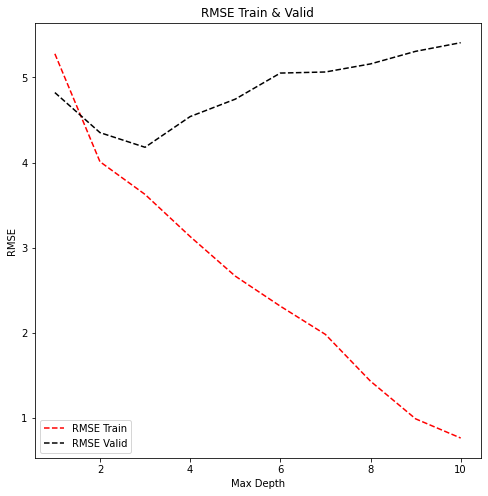

In [22]:
# Plot the RMSE train & valid.
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(8,8))

ax.plot(list_max_depth, list_rmse_train, "--r", label = "RMSE Train")
ax.plot(list_max_depth, list_rmse_valid, "--k", label = "RMSE Valid")

ax.set_xlabel("Max Depth")
ax.set_ylabel("RMSE")
ax.set_title("RMSE Train & Valid")
ax.legend()
plt.show()

## **3. Cross Validation Set Approach**
---

- We need a solution: Use **Cross Validation Set Approach**

In [23]:
fold_k = 5
list_number = list(range(1, 11))

for i in range(fold_k):
    print(f"Fold-{i+1} : {np.random.permutation(list_number)}")

Fold-1 : [ 3  2  4  9 10  7  6  1  5  8]
Fold-2 : [ 4  8  7  6  1  2  5 10  3  9]
Fold-3 : [ 3  8  9  1  2  5  4  7  6 10]
Fold-4 : [10  2  9  1  6  8  3  7  5  4]
Fold-5 : [ 7  2  6 10  4  9  8  1  3  5]


In [24]:
# Try permutation on mpg data.
new_auto_data = df_auto.reindex(np.random.permutation(df_auto.index))
new_auto_data.head()

,displacement,horsepower,weight,mpg
280,140.0,88.0,2890.0,22.3
276,89.0,71.0,1990.0,31.5
195,90.0,70.0,1937.0,29.0
58,97.0,54.0,2254.0,23.0
274,121.0,115.0,2795.0,21.6


In [25]:
# Before permutation.
df_auto.head()

,displacement,horsepower,weight,mpg
0,307.0,130.0,3504.0,18.0
1,350.0,165.0,3693.0,15.0
2,318.0,150.0,3436.0,18.0
3,304.0,150.0,3433.0,16.0
4,302.0,140.0,3449.0,17.0


In [26]:
# Reset index.
new_auto_data = new_auto_data.reset_index(drop = True)
new_auto_data.head()

,displacement,horsepower,weight,mpg
0,140.0,88.0,2890.0,22.3
1,89.0,71.0,1990.0,31.5
2,90.0,70.0,1937.0,29.0
3,97.0,54.0,2254.0,23.0
4,121.0,115.0,2795.0,21.6


- Define the `split_kfold` function.
- It receives 3 arguments: `X`, `y`, and `k` (number of fold).
- Let's simulate **5-fold CV**.

In [27]:
# Function to split using K-Fold Approach.
def split_kfold(data, n_fold=5):
    """
    Split the data using K-Fold Approach
    """
    # Get the indexes using permutation.
    indexes = np.random.permutation(data.index)

    new_data = data.reindex(indexes)
    new_data = new_data.reset_index(drop = True)

    X, y = split_input_output(new_data, OUTPUT_COL)

    n_data = len(X)
    fold_size = n_data // n_fold
    print(f"The number of data in each fold : {fold_size}")

    list_data_folds = []

    for i in range(n_fold):
        start_idx = i * fold_size
        end_idx = start_idx + fold_size

        X_valid = X[start_idx:end_idx]
        y_valid = y[start_idx:end_idx]

        X_train = pd.concat([X[:start_idx], X[end_idx:]],
                            axis = 0)
        y_train = pd.concat([y[:start_idx], y[end_idx:]],
                            axis = 0)

        list_data_folds.append((X_valid, y_valid, X_train, y_train))

        print(f"Fold-{i+1} X_valid :\n {X_valid}")
        print(f"Fold-{i+1} X_train :\n {X_train}\n")

    return list_data_folds

In [28]:
# Test the function.
data_folds = split_kfold(data = df_auto,
                         n_fold = 5)

The number of data in each fold : 78
Fold-1 X_valid :
     displacement  horsepower  weight
0          318.0       150.0  3777.0
1          122.0        88.0  2500.0
2          400.0       150.0  4997.0
3          112.0        88.0  2640.0
4          156.0       108.0  2930.0
..           ...         ...     ...
73         400.0       170.0  4746.0
74          97.0        67.0  1985.0
75         250.0        88.0  3139.0
76         267.0       125.0  3605.0
77          86.0        64.0  1875.0

[78 rows x 3 columns]
Fold-1 X_train :
      displacement  horsepower  weight
78           98.0        80.0  1915.0
79          302.0       130.0  4295.0
80          171.0        97.0  2984.0
81           97.0        54.0  2254.0
82          302.0       129.0  3725.0
..            ...         ...     ...
387         105.0        63.0  2125.0
388          83.0        61.0  2003.0
389          89.0        71.0  1925.0
390          98.0        70.0  2120.0
391         232.0        90.0  3265.0

[31

- Define the `evaluate_model` function.
- It receives 2 arguments: `data_folds` and `max_depth`.
- It simulates the model fitting, prediction, and evaluation.

In [29]:
# Function to evaluate model.
def evaluate_model(data_folds, max_depth=None):
    """
    Fit and evaluate the model.
    """
    # Initialization.
    list_rmse_train_cv = []
    list_rmse_valid_cv = []

    for i, (X_valid, y_valid, X_train, y_train) in enumerate(data_folds):
        dt_reg_i = DecisionTreeRegressor(max_depth=max_depth)
        dt_reg_i.fit(X_train, y_train)

        y_train_pred_i = dt_reg_i.predict(X_train)
        y_valid_pred_i = dt_reg_i.predict(X_valid)

        rmse_train_i = RMSE(y_train, y_train_pred_i)
        rmse_valid_i = RMSE(y_valid, y_valid_pred_i)

        list_rmse_train_cv.append(rmse_train_i)
        list_rmse_valid_cv.append(rmse_valid_i)

    cv_rmse_train = np.mean(list_rmse_train_cv)
    cv_rmse_valid = np.mean(list_rmse_valid_cv)
    print(f"CV RMSE Train : {cv_rmse_train:.4f}")
    print(f"CV RMSE Valid : {cv_rmse_valid:.4f}")

    return cv_rmse_train, cv_rmse_valid

In [30]:
# Test the function.
list_rmse_train_cv, list_rmse_valid_cv = evaluate_model(data_folds = data_folds)

CV RMSE Train : 0.2268
CV RMSE Valid : 4.7789


- Tune the `max_depth` of `DecisionTreeRegressor` similar to above experiment.

In [31]:
# Tune the max_depth of dt_reg.
list_max_depth = list(range(1, 11))

# Experiment.
list_rmse_train_cv = []
list_rmse_valid_cv = []

for depth in list_max_depth:
    print(f"Max Depth : {depth}")
    cv_train_i, cv_valid_i = evaluate_model(data_folds = data_folds,
                                            max_depth = depth)
    print("\n")

    list_rmse_train_cv.append(cv_train_i)
    list_rmse_valid_cv.append(cv_valid_i)

Max Depth : 1
CV RMSE Train : 5.0443
CV RMSE Valid : 5.0979


Max Depth : 2
CV RMSE Train : 3.9798
CV RMSE Valid : 4.2998


Max Depth : 3
CV RMSE Train : 3.6375
CV RMSE Valid : 4.1377


Max Depth : 4
CV RMSE Train : 3.2133
CV RMSE Valid : 4.3165


Max Depth : 5
CV RMSE Train : 2.8763
CV RMSE Valid : 4.3023


Max Depth : 6
CV RMSE Train : 2.5616
CV RMSE Valid : 4.2957


Max Depth : 7
CV RMSE Train : 2.2437
CV RMSE Valid : 4.3649


Max Depth : 8
CV RMSE Train : 1.8736
CV RMSE Valid : 4.2611


Max Depth : 9
CV RMSE Train : 1.4910
CV RMSE Valid : 4.3075


Max Depth : 10
CV RMSE Train : 1.0796
CV RMSE Valid : 4.6161




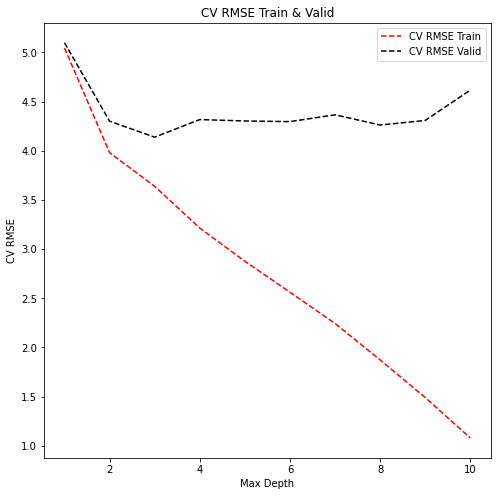

In [32]:
# Plot the CV RMSE train & valid.
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(8,8))

ax.plot(list_max_depth, list_rmse_train_cv, "--r", label = "CV RMSE Train")
ax.plot(list_max_depth, list_rmse_valid_cv, "--k", label = "CV RMSE Valid")

ax.set_xlabel("Max Depth")
ax.set_ylabel("CV RMSE")
ax.set_title("CV RMSE Train & Valid")
ax.legend()
plt.show()